# ReadSTM school workflow reproduction: `Helicene_Ag(111)008`

This notebook reproduces only the operations used in the school-provided
`ReadSTM_images.ipynb`, using `Helicene_Ag(111)008.sxm` as the target image.

**Processing boundary**

`SXM reading -> scan-direction correction -> NaN mean fill -> row/column mean subtraction -> Otsu threshold -> clear_border -> connected components -> 3 x 3 closing -> area/perimeter`

No Gaussian background subtraction, plane fitting, adaptive threshold,
watershed, Zernike moments, clustering, classification, parameter tuning, or
accuracy evaluation is added.

## What is an `.sxm` file?

An `.sxm` file is a **Nanonis scanning-probe microscopy data file**. Unlike a
PNG or JPEG, it is not a ready-made colour image. It stores a header containing
scan metadata and one or more numerical measurement channels. Common metadata
include scan direction, scan range, and pixel dimensions; common channels
include topographic height (`Z`) recorded during forward and backward scans.

The header values used here are:

- `scan_dir`: physical scan direction; a downward scan is vertically flipped
  so that all images use a consistent orientation.
- `scan_range`: physical width and height of the scanned region.
- `scan_pixels`: number of sampled pixels in each direction.
- `scan_range / scan_pixels`: physical size represented by one pixel.

## Notation used in this notebook

- $I(r,c)$：The height of the pixel at row $r$, col $c$.
- $H,W:$ The height and width of the image.
- $M(r,c):$ Mask with two values(0 & 1). 1 represents the pixel belongs to a molecule; 0 represents the pixel belongs to background.
- $L(r,c)$：Linked pixels.

These symbols describe the data at different stages: $I$ is the numerical STM
height image, $M$ is the foreground/background segmentation, and $L$ assigns a
separate integer identity to every connected foreground region.

## 1. Imports

Load the numerical, plotting, SXM-reading, thresholding, morphology, and region
measurement tools required by the school workflow. This step prepares the
environment and does not modify the STM image.

In [47]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# Compatibility only: nanonispy still refers to aliases removed in NumPy 2.x.
if not hasattr(np, "float"):
    np.float = float
if not hasattr(np, "int"):
    np.int = int

import nanonispy as nap
from skimage import filters, measure, segmentation
from skimage.color import label2rgb
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
from skimage.morphology import closing, square
from skimage.segmentation import clear_border
from skimage.morphology import footprint_rectangle

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt.rcParams["figure.dpi"] = 120

## 2. Read the SXM image exactly as demonstrated by the school

Read the forward `Z` height channel from `Helicene_Ag(111)008.sxm`. If the
header reports a downward scan, vertically flip the matrix once to standardise
its orientation. Any missing height values are replaced with the mean of the
valid values, as in the school SXM-reading example.

The physical pixel scale is calculated from

$$s_x=\frac{L_x}{N_x},\qquad s_y=\frac{L_y}{N_y},$$

where $L_x,L_y$ are the scan ranges and $N_x,N_y$ are the pixel counts.

In [34]:
DATA_FILE = Path(
    "/Volumes/Lexar/01-Active/Learning/monash课程文件/Year2 Semester2/"
    "ADS2002/Project/选题/CountingMolecules/ProjectData/Stetsovych Helicene/"
    "Helicene_Ag(111)008.sxm"
)

if not DATA_FILE.exists():
    raise FileNotFoundError(f"Target SXM file was not found: {DATA_FILE}")

scan = nap.read.Scan(str(DATA_FILE))
im = np.asarray(scan.signals["Z"]["forward"], dtype=float).copy()
scan_direction = scan.header["scan_dir"]

if scan_direction == "down":
    im = np.flipud(im)

missing_before_fill = int(np.isnan(im).sum())
if missing_before_fill:
    im[np.isnan(im)] = np.mean(im[~np.isnan(im)])

rescale = np.asarray(scan.header["scan_range"], dtype=float) / np.asarray(
    scan.header["scan_pixels"], dtype=float
)

print(f"Input file: {DATA_FILE}")
print(f"Image shape: {im.shape}")
print(f"Scan direction in header: {scan_direction}")
print(f"NaN values before mean fill: {missing_before_fill}")
print(f"Pixel scale: {rescale} m/pixel")
print(f"Pixel scale: {rescale * 1e9} nm/pixel")

Input file: /Volumes/Lexar/01-Active/Learning/monash课程文件/Year2 Semester2/ADS2002/Project/选题/CountingMolecules/ProjectData/Stetsovych Helicene/Helicene_Ag(111)008.sxm
Image shape: (1024, 1024)
Scan direction in header: down
NaN values before mean fill: 0
Pixel scale: [7.8125e-11 7.8125e-11] m/pixel
Pixel scale: [0.078125 0.078125] nm/pixel


## 3. Display the loaded STM image

Display the numerical height matrix using a pseudocolour map. This is a visual
quality-control step only: it does not modify `im` or create a new processed
image.

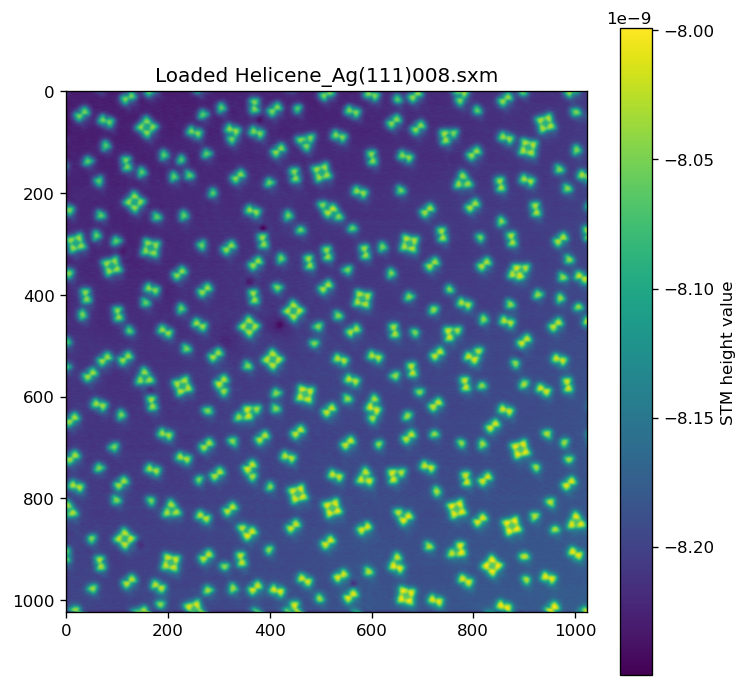

In [35]:
plt.figure(figsize=(7, 7))
plt.imshow(im)  # Map each measured height value to a display colour.
plt.title("Loaded Helicene_Ag(111)008.sxm")
plt.colorbar(label="STM height value")
plt.show()

## 4. Inspect three horizontal scan lines

This reproduces the notebook's inspection of the first, middle, and final image rows. It is a visual check of background offsets, scan-line variation, and molecular peaks.

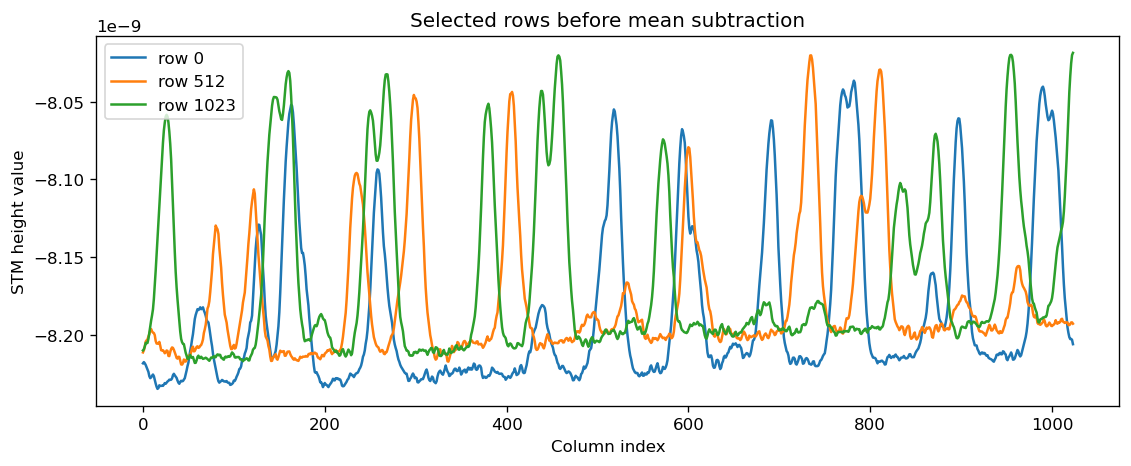

In [36]:
plt.figure(figsize=(11, 4))
plt.plot(im[:][0], label='row 0')
plt.plot(im[:][im.shape[0] // 2], label=f'row {im.shape[0] // 2}')    #choose three rows in the numeric metrix(top, middle, bottom) 
plt.plot(im[:][-1], label=f'row {im.shape[0] - 1}')                   #and check the values(height) in each line then draw the line chart
plt.xlabel('Column index')
plt.ylabel('STM height value')
plt.title('Selected rows before mean subtraction')
plt.legend()
plt.show()

## 5. Row/column mean-subtraction procedure

First calculate the mean of every column and subtract that vector from every row. Then calculate the mean of every corrected row and subtract that vector from every column. This is the original background-centering operation.

**Firstly:** Calculate the mean value of every column,
$$\mu_c=\frac{1}{H}\sum_{r=1}^{H}I(r,c)$$
**Then:** Minus this value from every pixel in this column,
$$I^{(1)}(r,c)=I(r,c)-\mu_c$$
**Secondly:** Do the same things on each row,
$$\nu_r=\frac{1}{W}\sum_{c=1}^{W}I^{(1)}(r,c)$$
$$I^{(2)}(r,c)=I^{(1)}(r,c)-\nu_r$$
**Combine this two step, this is "Double-centering":**
$$I^{(2)}(r,c)=I(r,c)-\mu_c-\rho_r+\mu$$

In [37]:
imslice = im
ind1 = np.arange(imslice.shape[0])
ind2 = np.arange(imslice.shape[1])

xm = np.mean(imslice, axis=0)
for ix in ind1:
    imslice[ix, :] = imslice[ix, :] - xm

ym = np.mean(imslice, axis=1)
for iy in ind2:
    imslice[:, iy] = imslice[:, iy] - ym

## 6. Check the remaining row and column means

After the subtraction, both curves should remain very close to zero. This is the same diagnostic used in `ReadSTM_images.ipynb`.

The plot shows that the remaining row and column means are close to zero after mean subtraction, indicating that double centering successfully removed the main row- and column-wise offsets

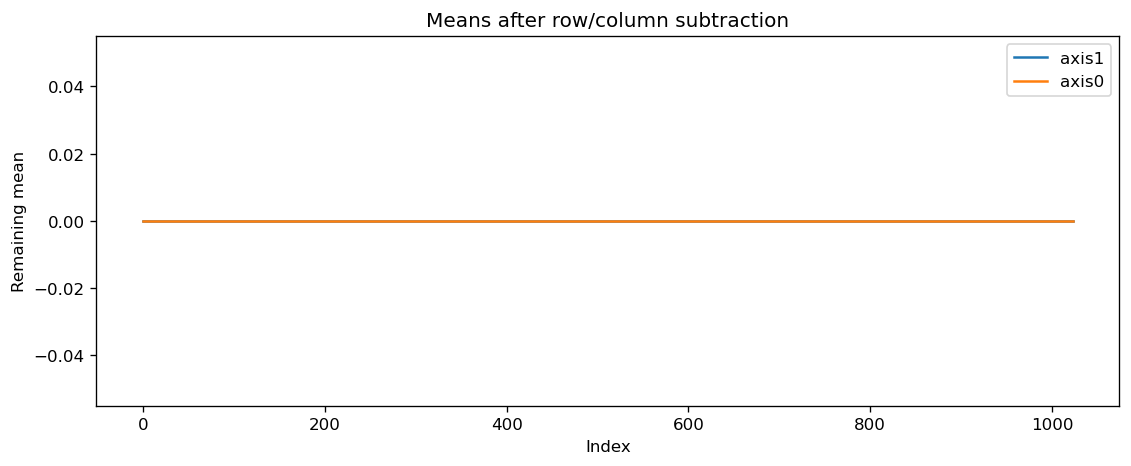

In [51]:
ym = np.mean(imslice, axis=1)
xm = np.mean(imslice, axis=0)

plt.figure(figsize=(11, 4))
plt.plot(ind2, xm, label='axis1')
plt.plot(ind1, ym, label='axis0')
plt.xlabel('Index')
plt.ylabel('Remaining mean')
plt.title('Means after row/column subtraction')
plt.legend()
plt.show()

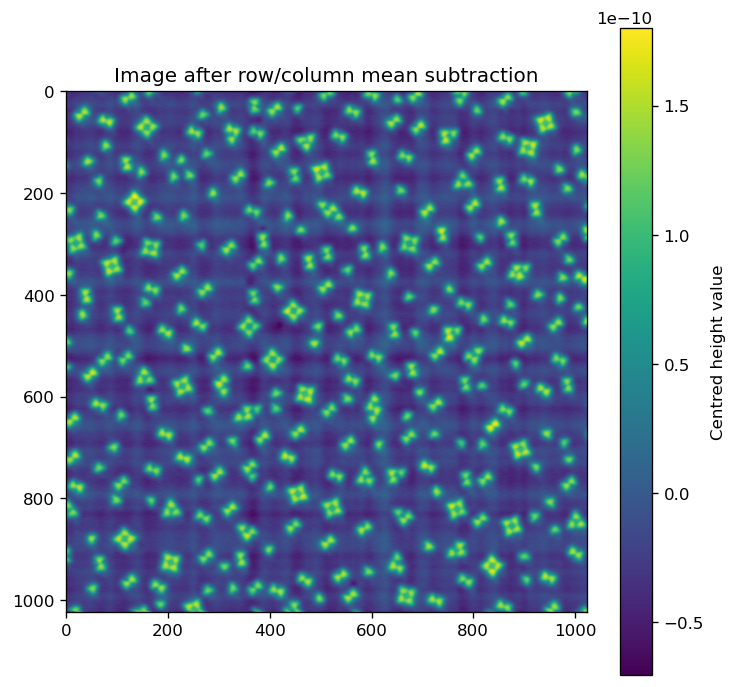

In [52]:
plt.figure(figsize=(7, 7))
plt.imshow(imslice)
plt.title('Image after row/column mean subtraction')
plt.colorbar(label='Centred height value')
plt.show()

## 7. Inspect selected vertical and horizontal profiles after subtraction

These plots reproduce the later line-profile checks in the notebook. The printed scalar is the mean of the complete processed matrix.

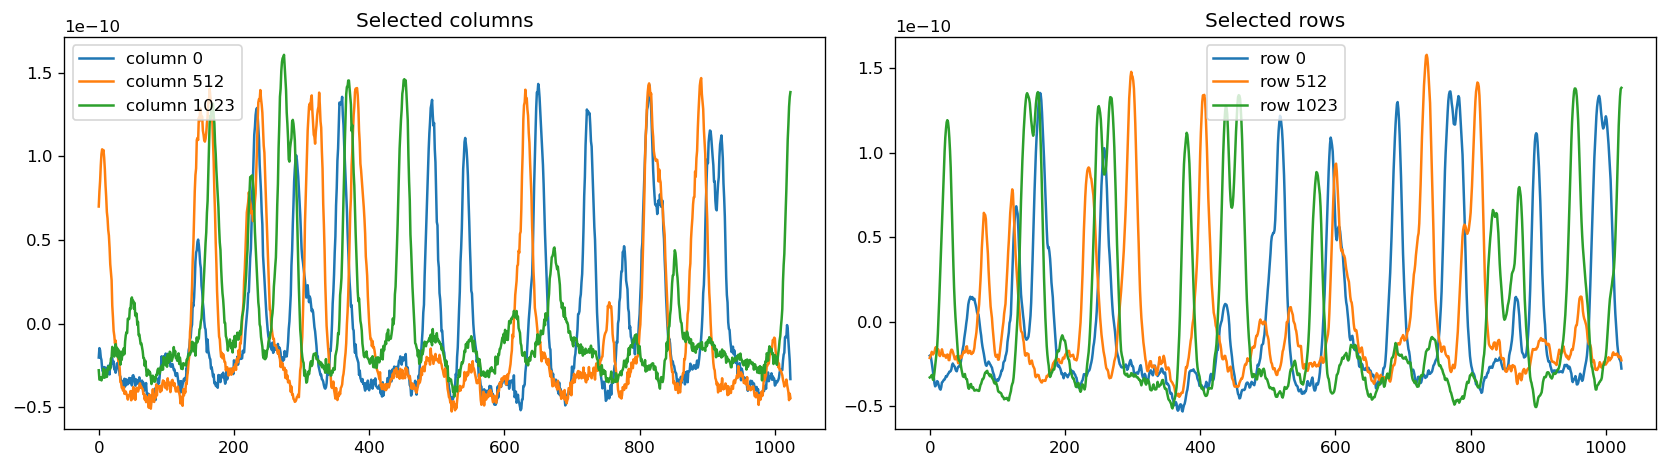

Processed image mean: 0.0


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(im[:, 0], label='column 0')
axes[0].plot(im[:, im.shape[1] // 2], label=f'column {im.shape[1] // 2}')
axes[0].plot(im[:, -1], label=f'column {im.shape[1] - 1}')
axes[0].set_title('Selected columns')
axes[0].legend()

axes[1].plot(imslice[0, :], label='row 0')
axes[1].plot(imslice[imslice.shape[0] // 2, :], label=f'row {imslice.shape[0] // 2}')
axes[1].plot(imslice[-1, :], label=f'row {imslice.shape[0] - 1}')
axes[1].set_title('Selected rows')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Processed image mean: {imslice.mean()}')

## 8. Global Otsu threshold and border clearing(Important)

Pixels above the global Otsu threshold become foreground. `clear_border` removes any connected foreground component touching an image border. `mark_boundaries` is calculated because it appears in the notebook, although that variable is not subsequently used there.

It follows this function:
$$M(r,c)=
\begin{cases}
1,&I^{(2)}(r,c)>T\\
0,&I^{(2)}(r,c)\leq T
\end{cases}$$

In addition, the threshold is chosen automatically:
$$T^*=\arg\max_T
\left[\omega_0(T)\omega_1(T)(\mu_0(T)-\mu_1(T))^2\right]$$

In [45]:
mask = imslice > filters.threshold_otsu(imslice)
clean_border = segmentation.clear_border(mask)
imslice_edges = segmentation.mark_boundaries(
    imslice, clean_border.astype(int)
)

print(f'Otsu threshold: {filters.threshold_otsu(imslice)}')
print(f'Foreground fraction after clear_border: {clean_border.mean():.3f}')

Otsu threshold: 3.565026274828556e-11
Foreground fraction after clear_border: 0.145


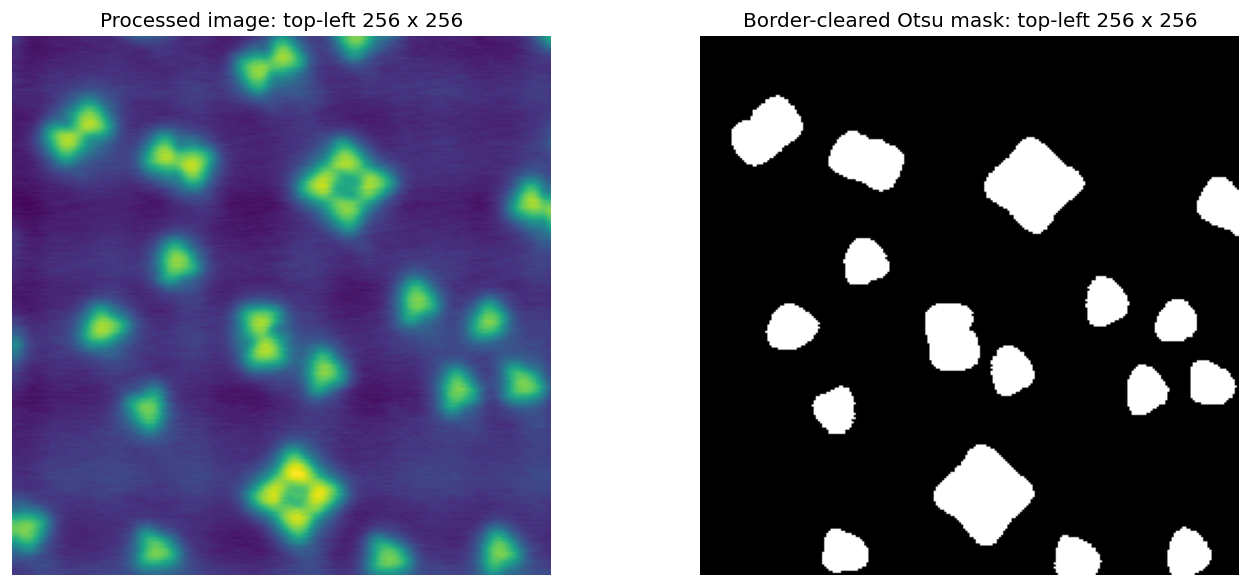

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(imslice[0:256, 0:256])
axes[0].set_title('Processed image: top-left 256 x 256')
axes[1].imshow(clean_border[0:256, 0:256], cmap='gray')
axes[1].set_title('Border-cleared Otsu mask: top-left 256 x 256')
for ax in axes:
    ax.set_axis_off()
plt.tight_layout()
plt.show()

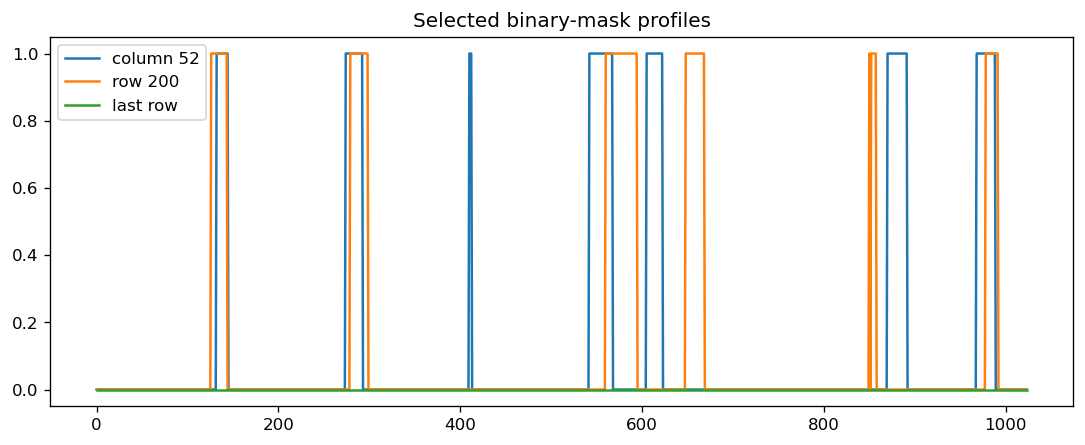

Mean of clean_border mask: 0.145


In [46]:
plt.figure(figsize=(11, 4))
plt.plot(clean_border[:, 52], label='column 52')
plt.plot(clean_border[200, :], label='row 200')
plt.plot(clean_border[-1, :], label='last row')
plt.title('Selected binary-mask profiles')
plt.legend()
plt.show()
print(f'Mean of clean_border mask: {clean_border.mean():.3f}')

## 9. Connected-component labelling

Every connected foreground region receives an integer label. Label 0 is background. These are detected blobs, not validated molecule classes.

In [12]:
blobs_labels = measure.label(clean_border, background=0)
unique_labels = np.unique(blobs_labels)

print(unique_labels)
print(f'Connected foreground regions: {len(unique_labels) - 1}')

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

## 10. Closing, relabelling, overlay, and bounding boxes

The threshold mask is processed with a 3 x 3 morphological closing, border-touching regions are removed again, and connected components are relabelled. A red bounding box is drawn only when `region.area >= 50`, exactly as in the notebook.

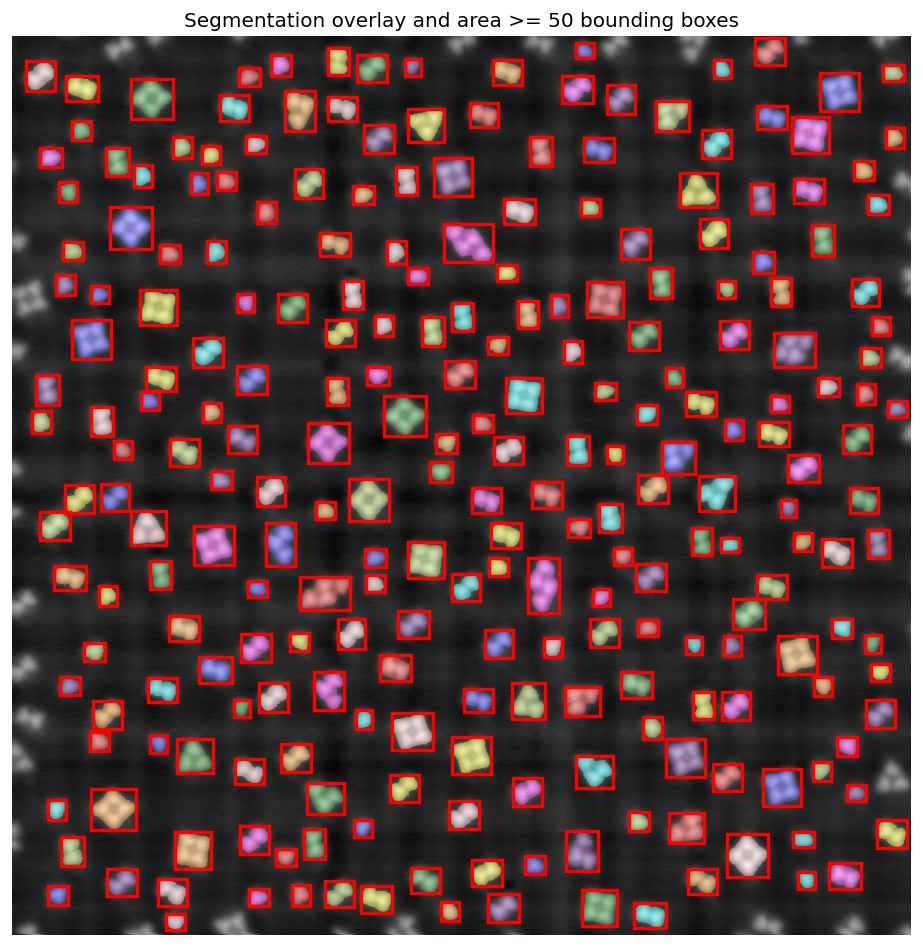

All labelled regions after closing: 249
Regions with area >= 50 and therefore boxed: 249


In [53]:
thresh = threshold_otsu(imslice)
bw = closing(
    imslice > thresh,
    footprint_rectangle((3, 3))
)

cleared = clear_border(bw)    #delete all the molecules that touch the border 
label_image = label(cleared)
display_image = (
    (imslice - imslice.min())
    / (imslice.max() - imslice.min())
)

image_label_overlay = label2rgb(
    label_image,
    image=display_image,
    bg_label=0
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(image_label_overlay)

boxed_regions = 0
for region in regionprops(label_image):
    if region.area >= 50:
        minr, minc, maxr, maxc = region.bbox
        rect = mpatches.Rectangle(
            (minc, minr),
            maxc - minc,
            maxr - minr,
            fill=False,
            edgecolor='red',
            linewidth=2,
        )
        ax.add_patch(rect)
        boxed_regions += 1

ax.set_title('Segmentation overlay and area >= 50 bounding boxes')
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f'All labelled regions after closing: {label_image.max()}')
print(f'Regions with area >= 50 and therefore boxed: {boxed_regions}')

## 11. Area and perimeter table

The school notebook extracts only `area` and `perimeter` from every labelled region and plots them against each other. It does not fit a clustering or classification model.

The area of each region is:
$$A_k=\sum_{r,c}\mathbf{1}[L(r,c)=k]$$

,area,perimeter
0,613.0,101.154329
1,259.0,59.112698
2,589.0,96.526912
3,388.0,73.355339
4,665.0,104.325902


Rows in the region-property table: 249


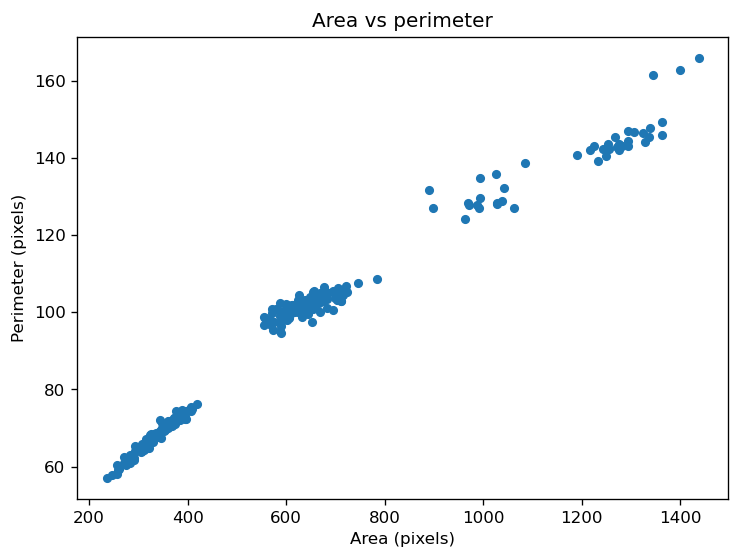

In [54]:
props = measure.regionprops_table(
    label_image, properties=('area', 'perimeter')
)
improps = pd.DataFrame(props)

display(improps.head())
print(f'Rows in the region-property table: {len(improps)}')

ax = improps.plot.scatter(
    x='area', y='perimeter', figsize=(7, 5), title='Area vs perimeter'
)
ax.set_xlabel('Area (pixels)')
ax.set_ylabel('Perimeter (pixels)')
plt.show()

### Interpretation of the area-perimeter distribution

Each point represents one of the 249 connected regions detected by the school preprocessing method. The x-axis shows the region area, while the y-axis shows its perimeter. Approximately four visually separated groups can be observed, suggesting that the detected molecules contain several distinct size categories. Area and perimeter are strongly positively correlated because larger segmented objects generally have longer boundaries.

However, the small-molecule observations in the lower-left part of the plot form one dense and overlapping group. If both P2 and P3 are located in this region, the school preprocessing method combined with area and perimeter features does not provide sufficient separation between them. This is reasonable because P2 and P3 have similar appearances and differ only slightly in molecular size and structure. Area and perimeter mainly describe overall object size and do not capture detailed internal or contour-shape differences.

Therefore, this result suggests that the school method may distinguish broad molecular size groups, but it is not sufficient for reliably separating the visually similar P2 and P3 molecules. Additional shape features and comparison with manually labelled ground truth will be required.

## End of the school workflow

The notebook intentionally stops at the same point as `ReadSTM_images.ipynb`: a segmented connected-component image and an area-perimeter scatter plot. No additional processing or interpretation is applied.